## Step 1 — Setup and reproducibility

Fixing the random seed means the same code gives the same result every run. The assignment asks for saved random seeds, so this cell is a graded requirement, not a nicety.

In [ ]:
import os, random, time, json, pathlib
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cpu':
    print('WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU')

Device: cuda


## Step 2 — Mount Google Drive

Colab wipes `/content/` when the runtime disconnects. Anything you want to keep (trained weights, results) must be written to Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUT = pathlib.Path('/content/drive/My Drive/cassava/custom_cnn')
OUT.mkdir(parents=True, exist_ok=True)
print('Results will be saved to:', OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/My Drive/cassava/custom_cnn


## Step 3 — Download the dataset from Kaggle

Get your API token first: Kaggle -> profile picture -> Settings -> API -> Create New Token. That downloads `kaggle.json`. Run the cell, then pick that file when prompted.

Never commit `kaggle.json` to GitHub. It is a credential. Add it to `.gitignore`.

In [ ]:
!pip install -q kaggle
from google.colab import userdata

import json, pathlib
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY      = userdata.get('KAGGLE_KEY')

p = pathlib.Path.home() / '.kaggle'
p.mkdir(exist_ok=True)
(p / 'kaggle.json').write_text(json.dumps(
    {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}))
(p / 'kaggle.json').chmod(0o600)

!kaggle datasets download -d nirmalsankalana/cassava-leaf-disease-classification
!unzip -q -o cassava-leaf-disease-classification.zip -d /content/raw
print('done')

Dataset URL: https://www.kaggle.com/datasets/nirmalsankalana/cassava-leaf-disease-classification
License(s): CC0-1.0
100% 2.39G/2.39G [00:18<00:00, 141MB/s]

done


## Step 4 — Check what actually downloaded

Never trust a dataset description. Count the files yourself. These numbers go straight into the Dataset Description section of the report.

In [ ]:
RAW = pathlib.Path('/content/raw')

EXTS = ('*.jpg', '*.jpeg', '*.png')
def imgs_in(d):
    out = []
    for e in EXTS:
        out += list(d.glob(e))
    return out

class_dirs = sorted([p for p in RAW.rglob('*') if p.is_dir() and imgs_in(p)])

total = 0
for d in class_dirs:
    n = len(imgs_in(d))
    total += n
    print(f'{d.name:35s} {n:6d}')
print(f'{"TOTAL":35s} {total:6d}')

CLASSES = [d.name for d in class_dirs]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print('\nClasses:', CLASS_TO_IDX)

Cassava___bacterial_blight            1087
Cassava___brown_streak_disease        2189
Cassava___green_mottle                2386
Cassava___healthy                     2577
Cassava___mosaic_disease             13158
TOTAL                                21397

Classes: {'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


## Step 5 — Resize once and cache

The originals are around 800x600. Decoding those every epoch is the slowest part of training. Resizing once to 256x256 and reusing the copies typically makes training 2-3x faster.

Why 256 and not 224: the model takes 224x224, but random cropping from a slightly larger image is a useful augmentation. Cache at 256, crop to 224.

This takes a few minutes. It only needs running once per session.

In [ ]:
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

CACHE = pathlib.Path('/content/cache256')
CACHE_SIZE = 256

jobs = []
for d in class_dirs:
    (CACHE / d.name).mkdir(parents=True, exist_ok=True)
    for f in imgs_in(d):
        jobs.append((f, CACHE / d.name / (f.stem + '.jpg')))

def resize_one(job):
    src, dst = job
    if dst.exists():
        return
    try:
        Image.open(src).convert('RGB').resize(
            (CACHE_SIZE, CACHE_SIZE), Image.BILINEAR).save(dst, quality=95)
    except Exception as e:
        print('skip', src, e)

t0 = time.time()
with ThreadPoolExecutor(8) as ex:
    list(ex.map(resize_one, jobs))
print(f'cached {len(jobs)} images in {time.time()-t0:.0f}s')

cached 21397 images in 138s


## Step 6 — Build the train / validation / test split

This is the most important cell in the notebook.

- **Train (70%)** — the model learns from these.
- **Validation (15%)** — used to choose when to stop and to tune settings.
- **Test (15%)** — touched exactly once, at the very end. The assignment says the test set must remain unseen.

`stratify` keeps the class proportions the same in all three splits. Without it, a rare class like bacterial blight could be badly represented in the test set by chance.

**Share `splits.csv` with your teammates.** All four models must train on identical data, or the comparison is not fair and you lose marks under Results.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

rows = []
for d in sorted(CACHE.iterdir()):
    if d.is_dir():
        for f in sorted(d.glob('*.jpg')):
            rows.append({'path': str(f), 'label': d.name})
df = pd.DataFrame(rows)
print('total images:', len(df))

trainval, test = train_test_split(
    df, test_size=0.15, stratify=df.label, random_state=SEED)
train, val = train_test_split(
    trainval, test_size=0.1765, stratify=trainval.label, random_state=SEED)

train = train.assign(split='train')
val   = val.assign(split='val')
test  = test.assign(split='test')
splits = pd.concat([train, val, test]).reset_index(drop=True)
splits.to_csv(OUT / 'splits.csv', index=False)

print(f'\ntrain {len(train)}  val {len(val)}  test {len(test)}')
print('\nclass balance per split (%):')
print((splits.groupby('split').label.value_counts(normalize=True)
       .unstack().round(3) * 100))

total images: 21397

train 14976  val 3211  test 3210

class balance per split (%):
label  Cassava___bacterial_blight  Cassava___brown_streak_disease  \
split                                                               
test                          5.1                            10.2   
train                         5.1                            10.2   
val                           5.1                            10.2   

label  Cassava___green_mottle  Cassava___healthy  Cassava___mosaic_disease  
split                                                                       
test                     11.2               12.1                      61.5  
train                    11.2               12.0                      61.5  
val                      11.1               12.1                      61.5  


## Step 7 — Look at the data

The report needs an exploratory data analysis section. These two figures cover the basics: what the class imbalance looks like, and what the images actually look like.

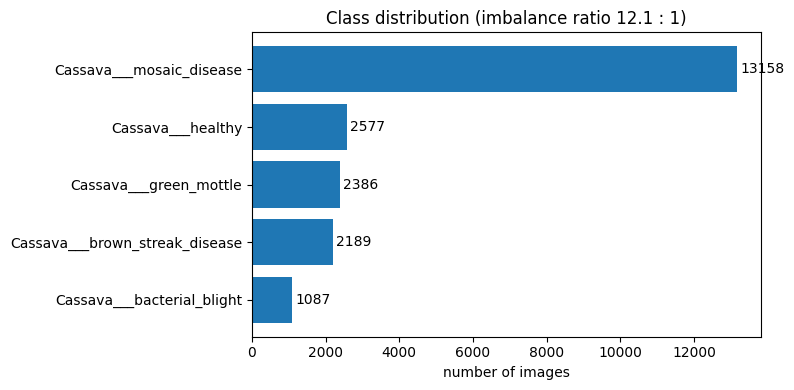

In [ ]:
import matplotlib.pyplot as plt

counts = df.label.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(counts.index, counts.values)
ax.set_xlabel('number of images')
ax.set_title('Class distribution (imbalance ratio '
             f'{counts.max()/counts.min():.1f} : 1)')
for i, v in enumerate(counts.values):
    ax.text(v + 100, i, str(v), va='center')
plt.tight_layout()
plt.savefig(OUT / 'class_distribution.png', dpi=150)
plt.show()

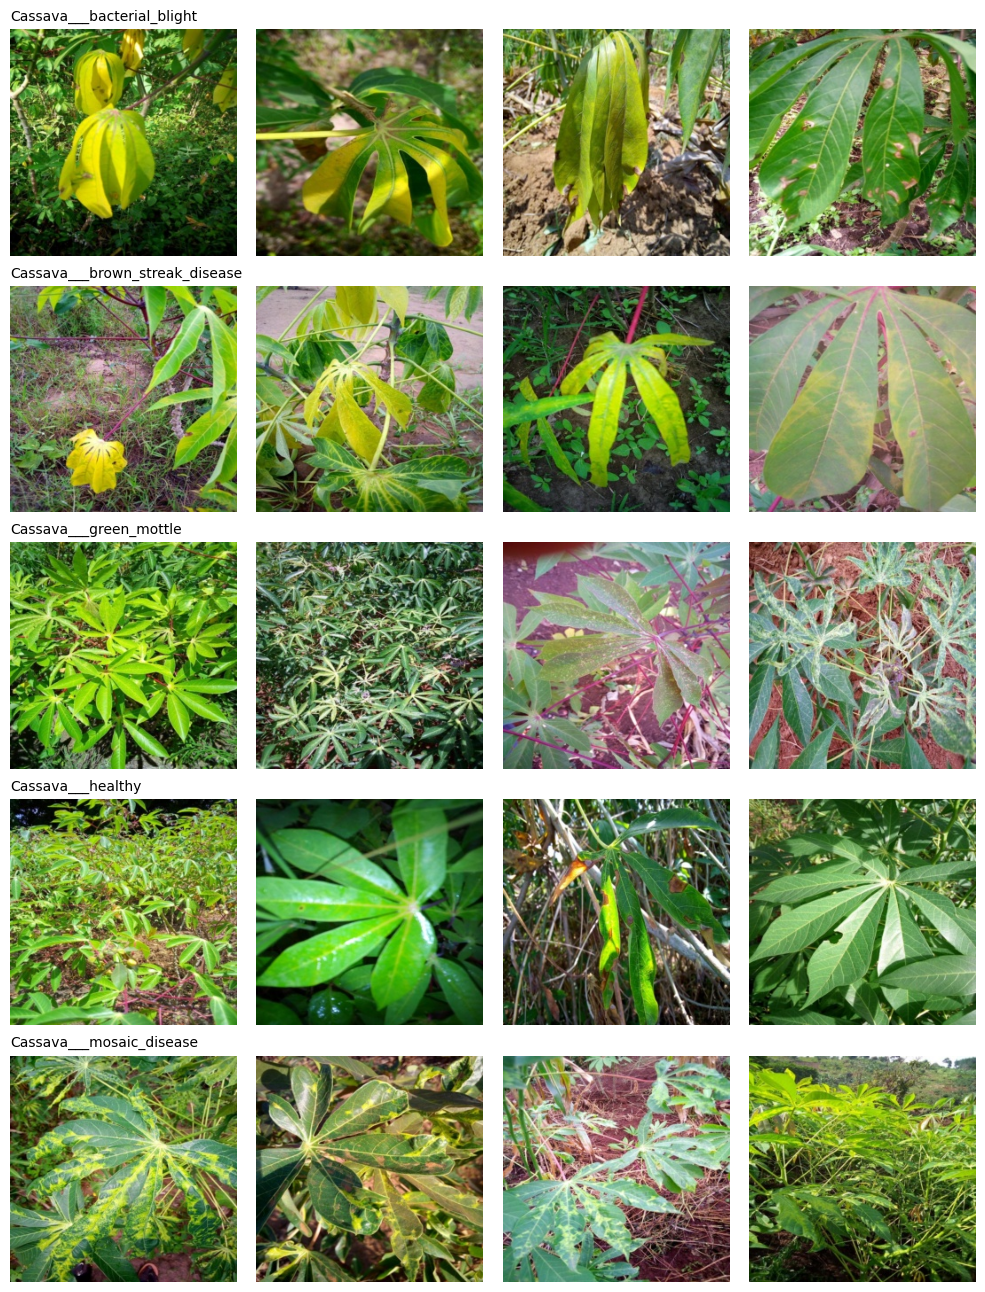

In [ ]:
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(10, 2.6 * len(CLASSES)))
for r, c in enumerate(CLASSES):
    sample = df[df.label == c].sample(4, random_state=SEED)
    for k, (_, row) in enumerate(sample.iterrows()):
        axes[r, k].imshow(Image.open(row.path))
        axes[r, k].axis('off')
    axes[r, 0].set_title(c, loc='left', fontsize=10)
plt.tight_layout()
plt.savefig(OUT / 'sample_images.png', dpi=130)
plt.show()

## Step 8 — Data loading and augmentation

Augmentation randomly alters training images (flips, rotations, brightness shifts) so the model sees more variety and memorises less. A leaf is still the same leaf upside down, so flips are safe here.

Augmentation is applied to the **training set only**. Validation and test must stay untouched, otherwise your measurements are noise.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG = 224
MEAN = [0.485, 0.456, 0.406]   # ImageNet stats, so all four models match
STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tfm = transforms.Compose([
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class CassavaDS(Dataset):
    def __init__(self, frame, tfm):
        self.df = frame.reset_index(drop=True)
        self.tfm = tfm
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = Image.open(r.path).convert('RGB')
        return self.tfm(img), CLASS_TO_IDX[r.label]

BATCH = 64
dl_train = DataLoader(CassavaDS(train, train_tfm), batch_size=BATCH, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
dl_val   = DataLoader(CassavaDS(val,   eval_tfm), batch_size=BATCH, shuffle=False,
                      num_workers=2, pin_memory=True)
dl_test  = DataLoader(CassavaDS(test,  eval_tfm), batch_size=BATCH, shuffle=False,
                      num_workers=2, pin_memory=True)

xb, yb = next(iter(dl_train))
print('batch shape:', xb.shape, 'labels:', yb[:8].tolist())

## Step 9 — The custom CNN architecture

Four blocks, each doing: convolution -> batch norm -> ReLU, twice, then halve the image size.

- **Conv2d** finds patterns. Early blocks learn edges and colours; later blocks learn textures and shapes like leaf spots.
- **BatchNorm2d** keeps values in a stable range so training does not diverge.
- **ReLU** adds non-linearity. Without it, stacking layers would be pointless.
- **MaxPool2d** halves width and height, so the network sees progressively larger context.
- **Channels double each block** (32 -> 64 -> 128 -> 256) as spatial size shrinks. Standard CNN design.
- **AdaptiveAvgPool2d(1)** collapses the final 14x14 map to one number per channel. Far fewer parameters than a large flatten + dense layer, so much less overfitting.
- **Dropout** randomly zeroes 40% of features during training, another overfitting guard.

Image size goes 224 -> 112 -> 56 -> 28 -> 14 through the four blocks.

Be ready to justify all of this in the viva. It is worth 10% under Appropriate learning algorithms.

In [ ]:
import torch.nn as nn

def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False),
        nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False),
        nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )

class CustomCNN(nn.Module):
    def __init__(self, n_classes=5, p_drop=0.4):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(256, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = CustomCNN(len(CLASSES)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {n_params:,}')

CustomCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inpl

## Step 10 — Loss, optimiser, class weights

Mosaic disease is roughly 12x more common than bacterial blight. Left alone, the model learns to guess mosaic and ignore the rare classes.

**Class weights** make mistakes on rare classes cost more, which forces the model to take them seriously. This choice is worth explaining in the report.

**Learning rate 1e-3**: appropriate for a network starting from random weights. Teammates fine-tuning pretrained models should use roughly 1e-4. Same learning rate for all four would cripple the pretrained ones, so do not copy this number across.

In [ ]:
counts_train = train.label.value_counts()
w = torch.tensor([len(train) / (len(CLASSES) * counts_train[c]) for c in CLASSES],
                 dtype=torch.float32, device=DEVICE)
print('class weights:')
for c, v in zip(CLASSES, w.tolist()):
    print(f'  {c:35s} {v:.3f}')

criterion = nn.CrossEntropyLoss(weight=w, label_smoothing=0.05)

EPOCHS = 30
LR = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))

CONFIG = {
    'seed': SEED, 'img_size': IMG, 'batch_size': BATCH, 'epochs': EPOCHS,
    'lr': LR, 'optimizer': 'AdamW', 'weight_decay': 1e-4,
    'scheduler': 'CosineAnnealingLR', 'label_smoothing': 0.05,
    'dropout': 0.4, 'class_weights': dict(zip(CLASSES, w.tolist())),
    'params': n_params, 'classes': CLASSES,
}
with open(OUT / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
print('\nconfig saved')

class weights:
  Cassava___bacterial_blight          3.936
  Cassava___brown_streak_disease      1.954
  Cassava___green_mottle              1.794
  Cassava___healthy                   1.661
  Cassava___mosaic_disease            0.325

config saved


/tmp/ipykernel_1424/2814915189.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == 'cuda'))


## Step 11 — Training

One epoch = one pass over all training images. After each epoch the model is checked on the validation set.

**We track macro-F1, not accuracy.** Accuracy is misleading with imbalanced data: always predicting mosaic scores about 61% while detecting nothing useful. Macro-F1 averages performance across all five classes equally, so ignoring rare classes is punished.

**Early stopping** saves the best epoch and stops if validation stops improving for 7 epochs, which prevents overfitting and saves time.

In [ ]:
from sklearn.metrics import f1_score

def run_epoch(loader, training):
    model.train() if training else model.eval()
    tot_loss, preds, trues = 0.0, [], []
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
                out = model(xb)
                loss = criterion(out, yb)
            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            tot_loss += loss.item() * xb.size(0)
            preds += out.argmax(1).cpu().tolist()
            trues += yb.cpu().tolist()
    acc = float(np.mean(np.array(preds) == np.array(trues)))
    f1 = f1_score(trues, preds, average='macro')
    return tot_loss / len(loader.dataset), acc, f1

history = {k: [] for k in ['train_loss','train_acc','train_f1',
                           'val_loss','val_acc','val_f1','lr','epoch_time']}
best_f1, patience, bad = -1.0, 7, 0
t_start = time.time()

for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_l, tr_a, tr_f = run_epoch(dl_train, True)
    va_l, va_a, va_f = run_epoch(dl_val, False)
    scheduler.step()
    dt = time.time() - t0

    for k, v in zip(history, [tr_l, tr_a, tr_f, va_l, va_a, va_f,
                              optimizer.param_groups[0]['lr'], dt]):
        history[k].append(v)

    flag = ''
    if va_f > best_f1:
        best_f1, bad = va_f, 0
        torch.save(model.state_dict(), OUT / 'best_model.pt')
        flag = '  <- best, saved'
    else:
        bad += 1

    print(f'ep {ep:02d}/{EPOCHS} | train loss {tr_l:.3f} f1 {tr_f:.3f} | '
          f'val loss {va_l:.3f} acc {va_a:.3f} f1 {va_f:.3f} | {dt:.0f}s{flag}')

    if bad >= patience:
        print(f'early stopping at epoch {ep}')
        break

total_train_time = time.time() - t_start
print(f'\ntotal training time: {total_train_time/60:.1f} min')
print(f'best validation macro-F1: {best_f1:.4f}')

with open(OUT / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):


ep 01/30 | train loss 1.622 f1 0.254 | val loss 1.525 acc 0.348 f1 0.262 | 138s  <- best, saved


/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):


ep 02/30 | train loss 1.550 f1 0.310 | val loss 1.446 acc 0.452 f1 0.372 | 135s  <- best, saved


/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):


...

ep 28/30 | train loss 1.033 f1 0.636 | val loss 0.991 acc 0.747 f1 0.652 | 138s


/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):


ep 29/30 | train loss 1.035 f1 0.637 | val loss 0.987 acc 0.756 f1 0.661 | 135s  <- best, saved


/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):
/tmp/ipykernel_1424/405887544.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == 'cuda')):


ep 30/30 | train loss 1.030 f1 0.637 | val loss 0.986 acc 0.749 f1 0.656 | 136s

total training time: 68.5 min
best validation macro-F1: 0.6613


## Step 12 — Learning curves

The assignment asks for learning curves explicitly.

How to read them: if training loss keeps falling while validation loss rises, the model is overfitting (memorising rather than generalising). If both stay high, it is underfitting. Say which one you see, and why, in the discussion section.

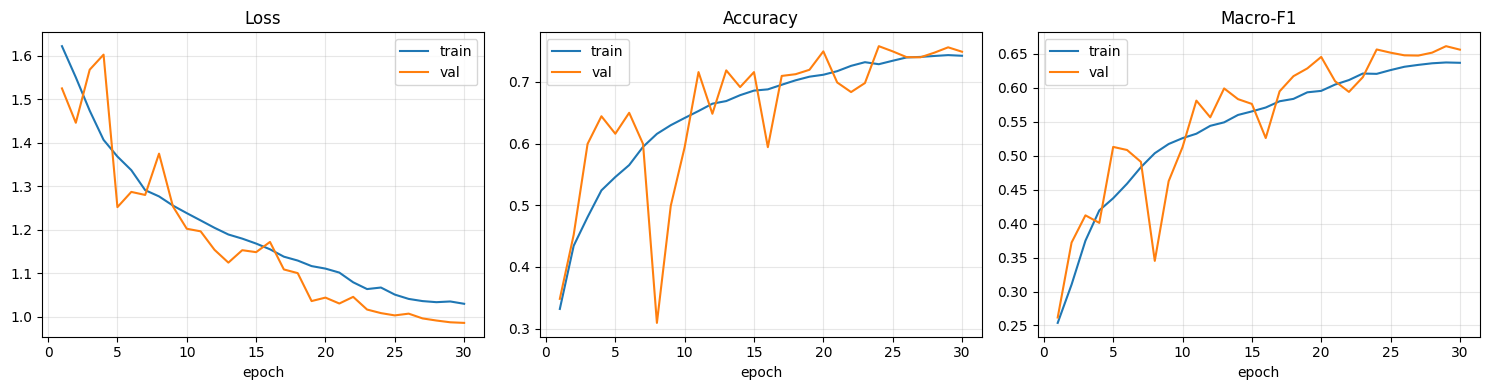

In [ ]:
ep_axis = range(1, len(history['train_loss']) + 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(ep_axis, history['train_loss'], label='train')
ax[0].plot(ep_axis, history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(ep_axis, history['train_acc'], label='train')
ax[1].plot(ep_axis, history['val_acc'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(ep_axis, history['train_f1'], label='train')
ax[2].plot(ep_axis, history['val_f1'], label='val')
ax[2].set_title('Macro-F1'); ax[2].set_xlabel('epoch'); ax[2].legend(); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.savefig(OUT / 'learning_curves.png', dpi=150)
plt.show()

## Step 13 — Final test evaluation

Run this **once**, at the very end, after all tuning is finished. Re-running it and then changing settings means the test set is no longer unseen, which is exactly the data leakage the assignment warns about.

The best checkpoint is reloaded first, because the final epoch is not necessarily the best one.

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

model.load_state_dict(torch.load(OUT / 'best_model.pt'))
model.eval()

all_prob, all_true = [], []
with torch.no_grad():
    for xb, yb in dl_test:
        xb = xb.to(DEVICE)
        prob = torch.softmax(model(xb).float(), dim=1).cpu().numpy()
        all_prob.append(prob)
        all_true += yb.tolist()

y_prob = np.concatenate(all_prob)
y_pred = y_prob.argmax(1)
y_true = np.array(all_true)

print('TEST SET RESULTS\n')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
acc = float((y_pred == y_true).mean())
f1m = f1_score(y_true, y_pred, average='macro')
f1w = f1_score(y_true, y_pred, average='weighted')
print(f'Accuracy       {acc:.4f}')
print(f'Macro-F1       {f1m:.4f}')
print(f'Weighted-F1    {f1w:.4f}')
print(f'Macro ROC-AUC  {auc:.4f}')

TEST SET RESULTS

                                precision    recall  f1-score   support

    Cassava___bacterial_blight     0.4097    0.5706    0.4769       163
Cassava___brown_streak_disease     0.6263    0.7104    0.6657       328
        Cassava___green_mottle     0.5874    0.7318    0.6517       358
             Cassava___healthy     0.4867    0.7080    0.5768       387
      Cassava___mosaic_disease     0.9694    0.7867    0.8686      1974

                      accuracy                         0.7523      3210
                     macro avg     0.6159    0.7015    0.6480      3210
                  weighted avg     0.8051    0.7523    0.7686      3210

Accuracy       0.7523
Macro-F1       0.6480
Weighted-F1    0.7686
Macro ROC-AUC  0.9277


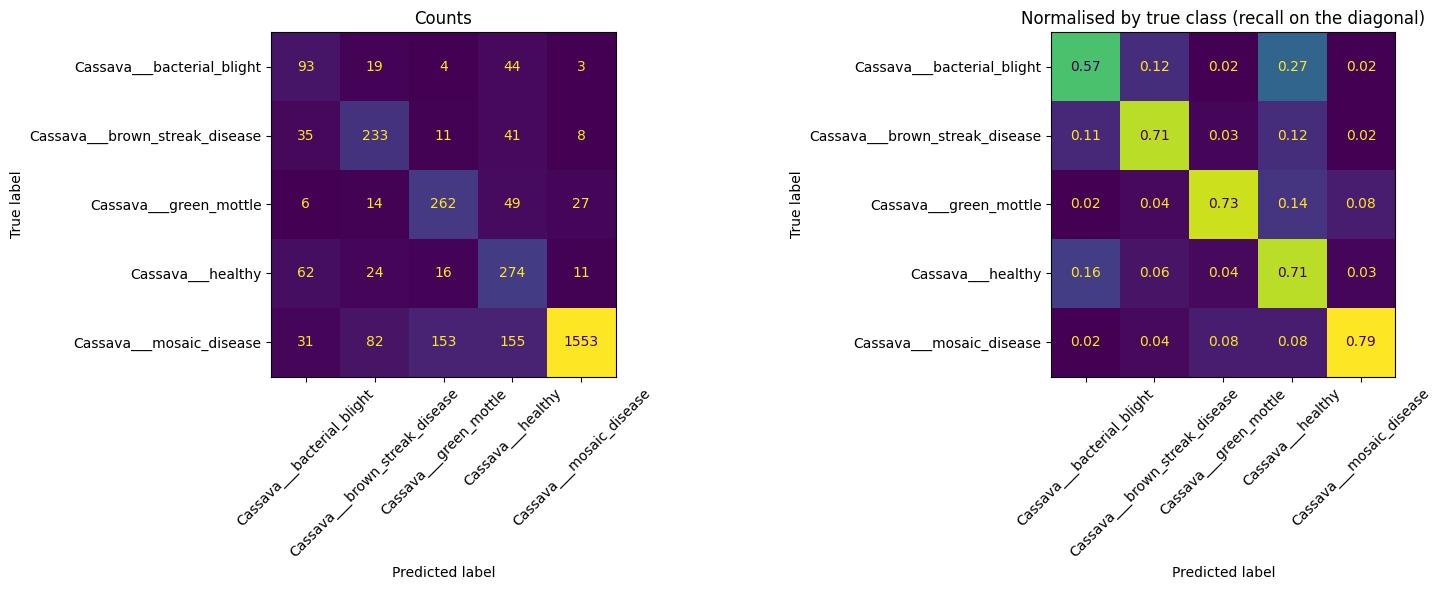

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                       display_labels=CLASSES).plot(ax=ax[0], xticks_rotation=45,
                                                    colorbar=False)
ax[0].set_title('Counts')

ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, normalize='true').round(2),
                       display_labels=CLASSES).plot(ax=ax[1], xticks_rotation=45,
                                                    colorbar=False)
ax[1].set_title('Normalised by true class (recall on the diagonal)')

plt.tight_layout()
plt.savefig(OUT / 'confusion_matrix.png', dpi=150)
plt.show()

## Step 14 — Efficiency measurements

The assignment asks for comparison on computational efficiency and model complexity, not just accuracy. These are the numbers for that table. Your custom CNN should win on size and speed while losing on accuracy, which is a useful trade-off to discuss.

In [ ]:
size_mb = os.path.getsize(OUT / 'best_model.pt') / 1e6

dummy = torch.randn(1, 3, IMG, IMG, device=DEVICE)
with torch.no_grad():
    for _ in range(10):
        model(dummy)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(100):
        model(dummy)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    latency_ms = (time.time() - t0) / 100 * 1000

summary = {
    'model': 'CustomCNN',
    'pretrained': False,
    'params': int(n_params),
    'model_size_mb': round(size_mb, 2),
    'epochs_run': len(history['train_loss']),
    'total_train_time_min': round(total_train_time / 60, 2),
    'mean_epoch_time_s': round(float(np.mean(history['epoch_time'])), 1),
    'inference_ms_per_image': round(latency_ms, 2),
    'best_val_macro_f1': round(float(best_f1), 4),
    'test_accuracy': round(acc, 4),
    'test_macro_f1': round(f1m, 4),
    'test_weighted_f1': round(f1w, 4),
    'test_macro_roc_auc': round(float(auc), 4),
}

with open(OUT / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

np.save(OUT / 'test_probs.npy', y_prob)
np.save(OUT / 'test_true.npy', y_true)

for k, v in summary.items():
    print(f'{k:28s} {v}')

## Step 15 — Inspect the worst mistakes

Optional, but this is where the marks are. Critical Analysis is worth 30%, and almost nobody does error analysis.

This shows the images the model got wrong while being most confident. Look at them and judge: is the model genuinely failing, or is the label wrong? This dataset is known to contain mislabelled images, and being able to say which is which is exactly the evidence-based interpretation the rubric rewards.

In [ ]:
test_r = test.reset_index(drop=True)
wrong = np.where(y_pred != y_true)[0]
conf = y_prob[wrong, y_pred[wrong]]
worst = wrong[np.argsort(-conf)][:12]

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for a, i in zip(axes.ravel(), worst):
    a.imshow(Image.open(test_r.iloc[i].path))
    a.set_title(f'true: {CLASSES[y_true[i]]}\npred: {CLASSES[y_pred[i]]} '
                f'({y_prob[i, y_pred[i]]:.2f})', fontsize=8)
    a.axis('off')
plt.suptitle('Most confident mistakes', y=1.0)
plt.tight_layout()
plt.savefig(OUT / 'worst_errors.png', dpi=130)
plt.show()